# Exercise 2 - Decision Tree for Playing Tennis



## Import Necessary Libraries

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

## Load the Dataset



In [8]:
!curl -L -o playtennis.zip https://www.kaggle.com/api/v1/datasets/download/fredericobreno/play-tennis && unzip -o playtennis.zip && rm playtennis.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   337  100   337    0     0    378      0 --:--:-- --:--:-- --:--:--   378
Archive:  playtennis.zip
  inflating: play_tennis.csv         


In [9]:
df = pd.read_csv('play_tennis.csv')

print(df.head())

  day   outlook  temp humidity    wind play
0  D1     Sunny   Hot     High    Weak   No
1  D2     Sunny   Hot     High  Strong   No
2  D3  Overcast   Hot     High    Weak  Yes
3  D4      Rain  Mild     High    Weak  Yes
4  D5      Rain  Cool   Normal    Weak  Yes


## Prepare the Data for the Model

In [ ]:
df_encoded = df.copy()
le_encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df[column])
    le_encoders[column] = le
print("Encoded Dataset:")
print(df_encoded.head())

Encoded Dataset:
   day  outlook  temp  humidity  wind  play
0    0        2     1         0     1     0
1    6        2     1         0     0     0
2    7        0     1         0     1     1
3    8        1     2         0     1     1
4    9        1     0         1     1     1


## Split Data, Train, and Evaluate Model

In [ ]:
X = df_encoded.drop('play', axis=1)
y = df_encoded['play']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0,stratify=y)

model = DecisionTreeClassifier(random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
class_names = le_encoders['play'].classes_
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



## Plotting the Confusion Matrix

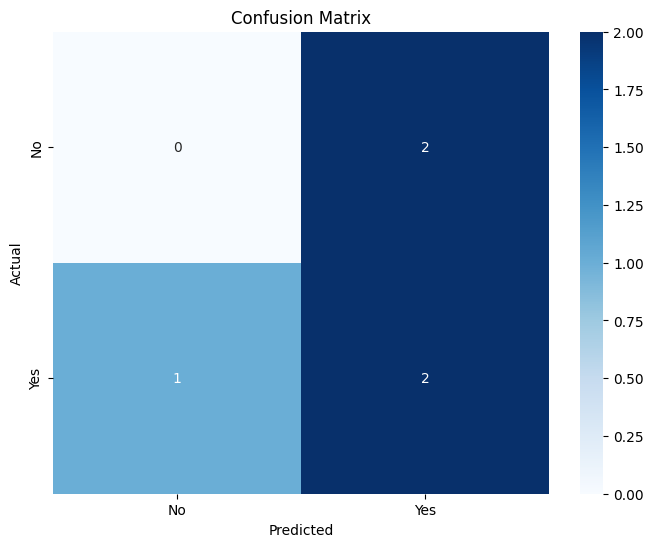

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()